# Replication: Denny & Spirling (2018) — Text Preprocessing For Unsupervised Learning

This notebook replicates a subset of the analysis from:

> Denny, M.J. & Spirling, A. (2018). "Text Preprocessing For Unsupervised Learning: Why It Matters, When It Misleads, And What To Do About It." *Political Analysis*, 26(2), 168–189.

**What this replication does:**
- Loads and analysis the main corpus refereced in the origianl study: the UK manifesto corpus
- Applies multiple and various preprocessing combinations (stemming, stopword removal, lowercasing, etc.)
- Builds term-document matrices under each combination
- Measures how much varying the preprocessing choices can change the results
- Visualises which preprocessing decisions are most impactful on the results

**Data source:** Harvard Dataverse (Denny & Spirling replication files)  
**Original code:** R (`preText` package on GitHub)  
**This replication:** Python (scikit-learn, nltk, pandas)

## Step 1: Install dependencies and import libraries

In [54]:
# Install pyreadr to read R data files
!pip install pyreadr -q

In [55]:
import pyreadr # now installed we can import pyreadr to read Rs data format
import pandas as pd
import numpy as np
import nltk # going to use this for text pre-processing such as stopword removal, stemming
import re # going to use this for text pre-processing: punctuation removal, number removal
import itertools # as we are going to be generating combinations of pre-processing steps, we'll use itertools for efficient looping over various combinations

# going to need to build feature vectors from the corpus to use:
# CountVectorizer - will be used to give sparse TDM
# TfidVectorizer - will be used to give TF-IDF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity #important to later analyse the difference in documents when we alter the pre processing steps

# for plotting and data visualisation:
import matplotlib.pyplot as plt
import seaborn as sns


nltk.download('stopwords', quiet=True) # commmon stopwords used in english language
from nltk.corpus import stopwords # imports stopwords as a list
from nltk.stem import SnowballStemmer # used to stem the words

print("All libraries loaded successfully.")

All libraries loaded successfully.


## Step 2: Upload and loading the data from the original study

Upload the `.RData` files from the Harvard Dataverse replication materials.  



In [56]:


# Download the UK Manifestos corpus directly from this project's GitHub repo.
# This means the notebook runs end-to-end without any manual file upload,
# satisfying the assignment requirement of single-execution reproducibility.
import urllib.request

url = "https://raw.githubusercontent.com/amiraalshabazz-spec/denny-spirling-replication-/main/UK_Manifestos.RData"
urllib.request.urlretrieve(url, "UK_Manifestos.RData")
print("UK_Manifestos.RData downloaded successfully from GitHub.")

UK_Manifestos.RData downloaded successfully from GitHub.


In [57]:
# Load and read the UK Manifestos corpus from the .RData file and return dictionary like object.
# dictionary has only one object 'documents'
all_data = pyreadr.read_r('UK_Manifestos.RData')



## Step 3: Extract and prepare the corpus

The .RData file has been loaded into `all_data` as a dictionary of
pandas objects. We now pull out the manifesto corpus and convert it
into a plain Python list of strings to be used later in the preprocessing
functions.

In [58]:
corpus_df = all_data['documents'] # creating data frame from key in dictionary of 'documents'
# each row of data frame has raw text of each manifesto, we want to convert each manifesto to a plain python list of strings
documents = corpus_df['documents'].tolist()

# lets check the documents are all reading correctly
char_lengths = [len(d) for d in documents]
word_lengths = [len(d.split()) for d in documents]
print(f"Average document length: {int(np.mean(word_lengths))} words ({int(np.mean(char_lengths))} chars)")
print(f"Shortest: {min(word_lengths)} words  |  Longest: {max(word_lengths)} words")
print(f"\nFirst 300 characters of the first manifesto:\n")
print(documents[0][:300])

Average document length: 7450 words (46142 chars)
Shortest: 835 words  |  Longest: 30365 words

First 300 characters of the first manifesto:

1918 Conservative Party General Election Manifesto The Manifesto of Lloyd George and Bonar Law  The Coalition Government, supported by the strenuous and united labours of the whole nation, has now accomplished the gravest portion of its task. Our enemies have been defeated in the field, their armies


## Step 4: Define preprocessing functions

These are the individual preprocessing steps that Denny & Spirling test.  
Each function takes a list of document strings and returns a processed list.

In [59]:
# Initialise tools
stemmer = SnowballStemmer('english') # to use stemming rules for the english language
stop_words = set(stopwords.words('english')) # create set of common english stop words (and, a, the, etc)


def apply_lowercasing(texts):
    """Convert all text to lowercase."""
    return [t.lower() for t in texts]


def apply_stemming(texts):
    """Reduce words to their stems using the Snowball (Porter2) stemmer."""
    def stem_doc(doc):
        words = doc.split() # splits document string into list of words
        return ' '.join([stemmer.stem(w) for w in words]) # stemms each word then rejoins them into single string with spaces
    return [stem_doc(t) for t in texts] # want to appluy stemm_doc to each document in the list


def apply_stopword_removal(texts):
    """Remove common English stopwords."""
    def remove_stops(doc):
        words = doc.split()
        # for every word in the document if the lowercase version of the word is NOT a stop word then keep the word. (stopword set is all in lowercase)
        # rejoin the words that aren't stop words, back into single string
        return ' '.join([w for w in words if w.lower() not in stop_words])
    return [remove_stops(t) for t in texts]


def apply_punctuation_removal(texts):
    """Remove all punctuation characters."""
    # for every document replace the anything thats NOT a letter, digit, underscore, or whitespace with a ' ' (space)
    return [re.sub(r'[^\w\s]', '', t) for t in texts]


def apply_number_removal(texts):
    """Remove all numeric characters."""
    # use d+ to substitute consecutive digits with ' ' (space)
    return [re.sub(r'\d+', '', t) for t in texts]


print("Preprocessing functions defined.")

Preprocessing functions defined.


## Step 5: Build preprocessing pipelines

Denny & Spirling test 128 combinations (7 binary choices). We'll test a focused subset of **32 combinations** using 5 binary preprocessing decisions:

1. Lowercase (yes/no) (L)
2. Remove punctuation (yes/no) (P)
3. Remove numbers (yes/no) (N)
4. Remove stopwords (yes/no) (W)
5. Stem (yes/no) (S)

The 32 combinations with 5 pre-processing decisions will replicate the sensitivity of the pre-processing steps and order, whilst also keeping the replication manageable and fast processing speed.


In [60]:
# Define the preprocessing steps and their on/off states
preprocessing_steps = {
    'lowercase': apply_lowercasing,
    'remove_punctuation': apply_punctuation_removal,
    'remove_numbers': apply_number_removal,
    'remove_stopwords': apply_stopword_removal,
    'stem': apply_stemming
}

# Generate all 2^5 = 32 combinations of on/off for each step
step_names = list(preprocessing_steps.keys()) # keys of the dictionary are the names of the pre-processing steps and here we create a list of them
# create list of the possible combination of every 5-tuple where each position is either False or True for each pre-processing step
combinations = list(itertools.product([False, True], repeat=len(step_names)))

print(f"Number of preprocessing pipelines to test: {len(combinations)}")
# need to bring togther the step names and whether true or false
print(f"\nExample pipeline (all steps ON): {dict(zip(step_names, combinations[-1]))}") # last tuple in the list, paired with each pre-processing step, and puts into dictionary
print(f"Example pipeline (all steps OFF): {dict(zip(step_names, combinations[0]))}") # does the same but with the first tuple

Number of preprocessing pipelines to test: 32

Example pipeline (all steps ON): {'lowercase': True, 'remove_punctuation': True, 'remove_numbers': True, 'remove_stopwords': True, 'stem': True}
Example pipeline (all steps OFF): {'lowercase': False, 'remove_punctuation': False, 'remove_numbers': False, 'remove_stopwords': False, 'stem': False}


In [61]:
def run_pipeline(documents, combination, step_names, preprocessing_steps):
    """
    Apply a specific combination of preprocessing steps to the documents.

    Args:
        documents: list of raw document strings
        combination: tuple of booleans indicating which steps to apply
        step_names: list of step names (matching the combination order)
        preprocessing_steps: dict mapping step names to functions

    Returns:
        list of preprocessed document strings
    """
    processed = documents.copy() # need to create a copy of the document so every pipeline starts from same place
    # loop over each of the 5 pre-processing steps check if step is turned on (TRUE) and if not we skip it
    for step_name, apply_step in zip(step_names, combination):
        if apply_step:
            processed = preprocessing_steps[step_name](processed) # now process the copy of the document with the processing steps that are TRUE for the pipeline
    return processed # loop over new processed document for each step


# now need to build document term matrix from processed document
def build_TDM(processed_docs):
    """
    Build a term-document matrix from preprocessed documents using term frequency.

    Returns:
        Sparse term-document matrix and the fitted vectorizer
    """
    vectorizer = CountVectorizer(max_features=5000) # cap vocab at 5000 most frequant words to remove the noise
    # use CountVectorizer to return sparse matrix so we dont have non-zero values
    vectorizer.fit(processed_docs) # identify every unique word and assigns each one a column index
    TDM = vectorizer.transform(processed_docs) # count how often each vocab word appears in each document
    return TDM, vectorizer


print("Pipeline and TDM functions defined.")

Pipeline and TDM functions defined.


## Step 6: Run all pipelines and compute document similarity matrices

For each preprocessing pipeline, we:
1. Preprocess the documents
2. Build a term-document matrix
3. Compute pairwise cosine similarity between all documents

This follows Denny & Spirling's approach: if preprocessing choices don't matter, the similarity rankings between documents should be stable across pipelines.

In [62]:
# Store results: a cosine similarity matrix for each pipeline
pipeline_results = {} # create empty dictionary to call upon later
pipeline_labels = [] # create empty list

for i, combo in enumerate(combinations): # iterating across all 32 tuples with enumerate giving index and item
    # Create a readable label for this pipeline for step_names that are true
    label = '+'.join([name for name, on in zip(step_names, combo) if on])
    if not label: # if all steps are FALSE (turned off) no pre-processing is done
        label = 'no_preprocessing'
    pipeline_labels.append(label) # append list with pipeline list

    # Run the preprocessing pipeline - applies every ON step in order and gives preprocessed documents
    processed = run_pipeline(documents, combo, step_names, preprocessing_steps)

    # Build term-document matrix of processed matrix and only return TDM not vectorizer
    TDM, _ = build_TDM(processed)

    # Compute pairwise cosine similarity between documents as done in original paper
    sim_matrix = cosine_similarity(TDM)
    pipeline_results[label] = sim_matrix # stores similarity matrix in dictionary keyed by pipeline label


print(f"\nDone! Ran {len(pipeline_results)} preprocessing pipelines.")


Done! Ran 32 preprocessing pipelines.


## Step 7: Measure preprocessing sensitivity

Replicating Denny & Spirling, lets measure how much each preprocessing step shifts the results by comparing the cosine similarity matrices across pipelines.

The key metric: for each preprocessing step, we compare all pipelines where that step is ON vs OFF (holding everything else constant) and measure the average difference in document similarity rankings.

In [63]:
def compute_step_sensitivity(pipeline_results, combinations, step_names):
    """
    For each preprocessing step, compute how much turning it on vs off
    changes the document similarity matrix (averaged across all other
    pipeline configurations), replicating Denny & Spirling's preText diagnostic.

    Returns:
        Dictionary mapping each step name to its average effect size
        (mean absolute difference in cosine similarity values)
    """
    sensitivity = {} # empty dictionary to hold results
    labels = list(pipeline_results.keys()) # ordered list of pipeline labels

    for step_idx, step_name in enumerate(step_names): # iterating through 5 pre-procesing steps
        diffs = [] # list we'll use to collect pairwise differences

        # Find all pairs of pipelines that differ ONLY in this step
        for i, combo_a in enumerate(combinations):
            for j, combo_b in enumerate(combinations):
                if i >= j: # only looking at each unordered pair once
                    continue
                # Check: do they differ only in the current step?
                differs_only_here = True
                for k in range(len(step_names)): # for each position we check if two combination match or differ
                    if k == step_idx: # if we're looking at position of pre processing step we're measuring sensitivity of
                        if combo_a[k] == combo_b[k]:  # if the two combination have same boolean (both true or both false) then break loop
                            differs_only_here = False
                            break
                    else: # if we're not at the index of the pre processing step we're measuring sensitivity of then we want combinations to match
                        if combo_a[k] != combo_b[k]:
                            differs_only_here = False # if combinations of steps we're not measuring step of don't match then break loop
                            break

                if differs_only_here:
                    sim_a = pipeline_results[labels[i]]
                    sim_b = pipeline_results[labels[j]]
                    # Mean absolute difference between similarity matrices
                    diff = np.mean(np.abs(sim_a - sim_b))
                    diffs.append(diff)

        sensitivity[step_name] = np.mean(diffs) if diffs else 0

    return sensitivity


sensitivity = compute_step_sensitivity(pipeline_results, combinations, step_names)

print("Preprocessing step sensitivity (mean absolute difference in cosine similarity):")
# lets order sensitivity dictionary and loop through from highest sensitivity to lowest so looking at index [1] of sensitivity tuple
for step, score in sorted(sensitivity.items(), key=lambda x: x[1], reverse=True):
    print(f"  {step}  {score:.6f}")

Preprocessing step sensitivity (mean absolute difference in cosine similarity):
  remove_stopwords  0.394966
  stem  0.023852
  remove_punctuation  0.007688
  remove_numbers  0.000476
  lowercase  0.000000


## Step 8: Visualise the results

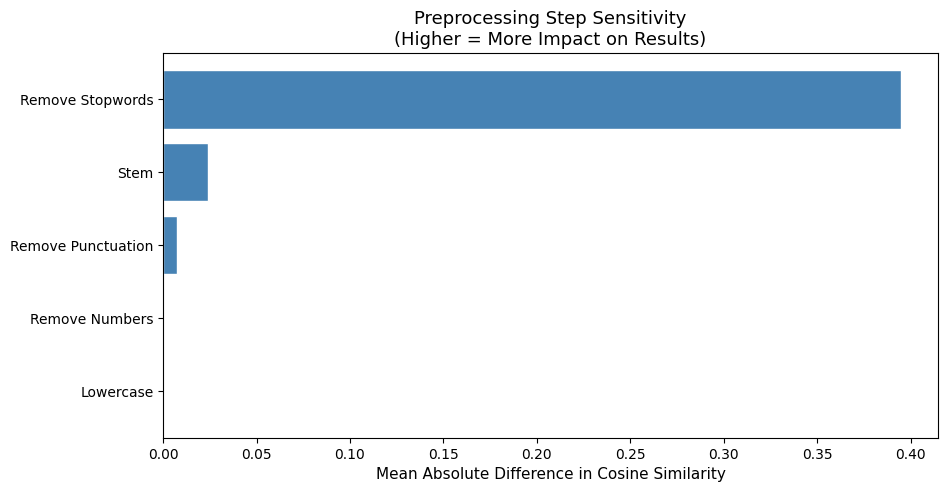

In [64]:
# --- Plot 1: Bar chart of preprocessing sensitivity ---
# This is my equivalent of Denny & Spirling's preText diagnostic plot

sorted_steps = sorted(sensitivity.items(), key=lambda x: x[1], reverse=True)
names = [s[0].replace('_', ' ').title() for s in sorted_steps] # takes step names and formats nicely
scores = [s[1] for s in sorted_steps]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names[::-1], scores[::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Mean Absolute Difference in Cosine Similarity', fontsize=11)
ax.set_title('Preprocessing Step Sensitivity\n(Higher = More Impact on Results)', fontsize=13)
plt.show()

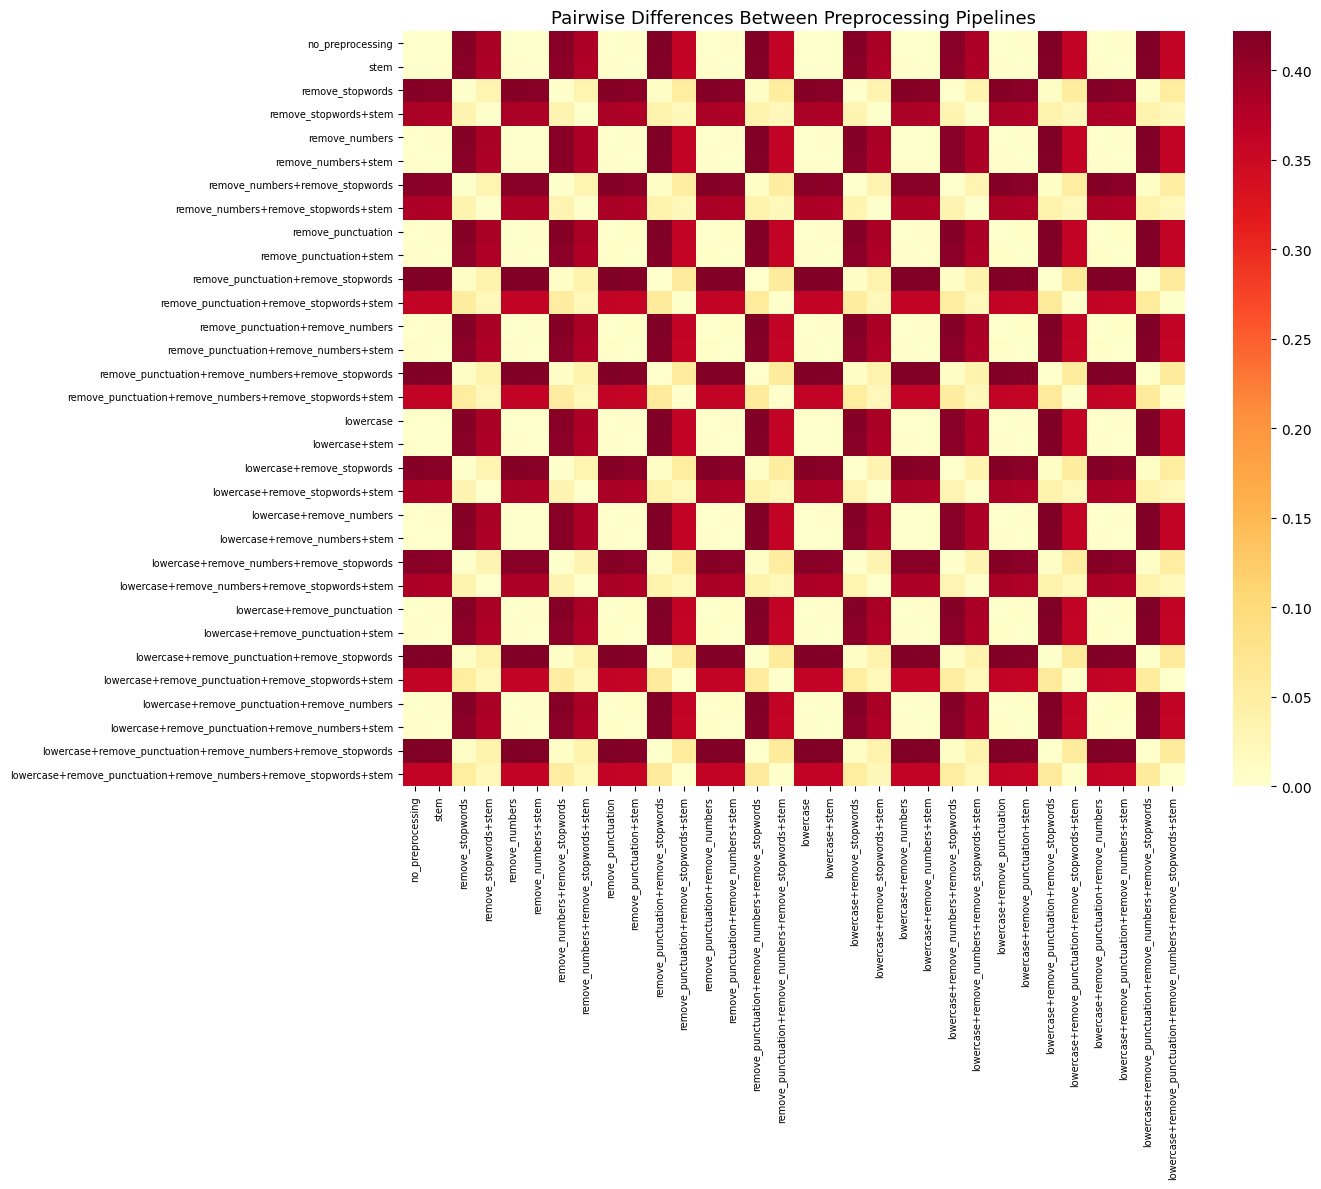

In [65]:
# --- Plot 2: Heatmap showing variation across all pipelines ---
# Compare how different the similarity matrices are across ALL pipeline pairs

n_pipelines = len(pipeline_results)
labels = list(pipeline_results.keys())
cross_pipeline_diffs = np.zeros((n_pipelines, n_pipelines)) # 32×32 numpy array filled with zeros.

for i in range(n_pipelines):
    for j in range(n_pipelines):
        cross_pipeline_diffs[i, j] = np.mean(
            np.abs(pipeline_results[labels[i]] - pipeline_results[labels[j]])
        ) # For each cell, compute how different pipeline i's cosine similarity output is from pipeline j's output.

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cross_pipeline_diffs,
    cmap='YlOrRd',
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)
ax.set_title('Pairwise Differences Between Preprocessing Pipelines', fontsize=13)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

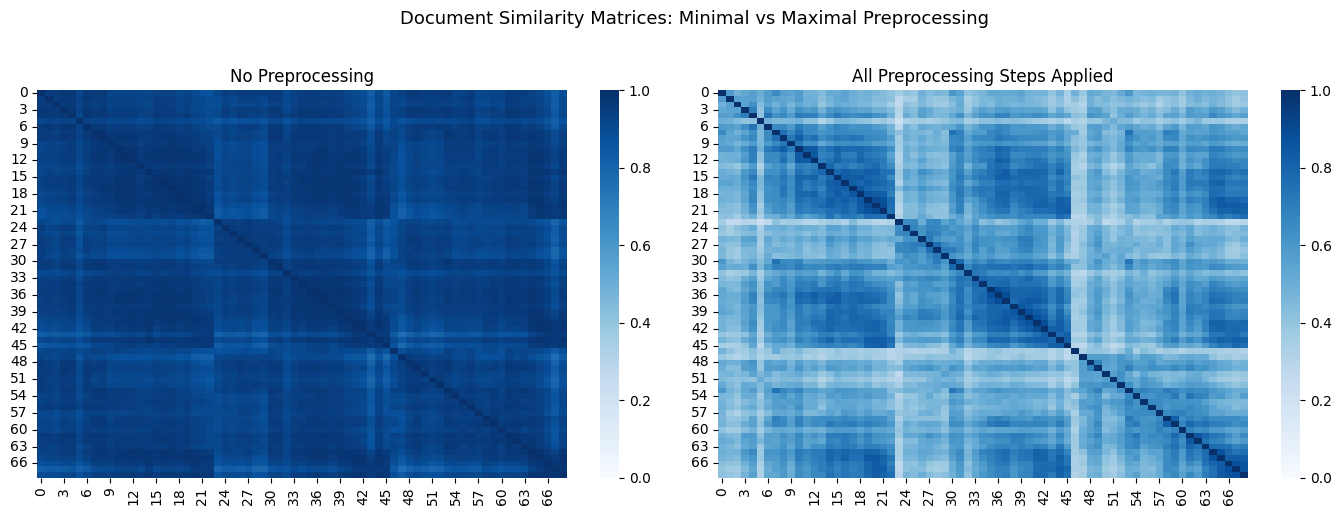

In [66]:
# --- Plot 3: Compare document similarity under two contrasting pipelines ---
# Shows how the same documents look different depending on preprocessing

# Minimal preprocessing (no preprocessing at all)
sim_none = pipeline_results.get('no_preprocessing')

# Maximal preprocessing (all steps on)
max_label = '+'.join(step_names)
sim_all = pipeline_results.get(max_label)

if sim_none is not None and sim_all is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(sim_none, cmap='Blues', ax=axes[0], vmin=0, vmax=1)
    axes[0].set_title('No Preprocessing', fontsize=12)

    sns.heatmap(sim_all, cmap='Blues', ax=axes[1], vmin=0, vmax=1)
    axes[1].set_title('All Preprocessing Steps Applied', fontsize=12)

    fig.suptitle('Document Similarity Matrices: Minimal vs Maximal Preprocessing', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Could not find the no-preprocessing or all-preprocessing pipeline in results.")
    print(f"Available pipelines: {list(pipeline_results.keys())[:5]}...")

## Direct Replication of Figure 5 (preText Regression Coefficient Plot)

The bar chart above summarises each preprocessing step's average effect using a
simple mean-absolute-difference metric. The original paper takes a more formal
approach: it fits an OLS regression where the outcome is each pipeline's distance
from the *mean* pipeline (the consensus across all 32 combinations), and the
predictors are binary flags for each preprocessing step. The regression coefficients
— plotted with 95% confidence intervals — are what appear in Figure 5 of the paper.

This cell reproduces that regression directly, giving us a plot that maps one-to-one
onto Figure 5 of Denny & Spirling (2018).

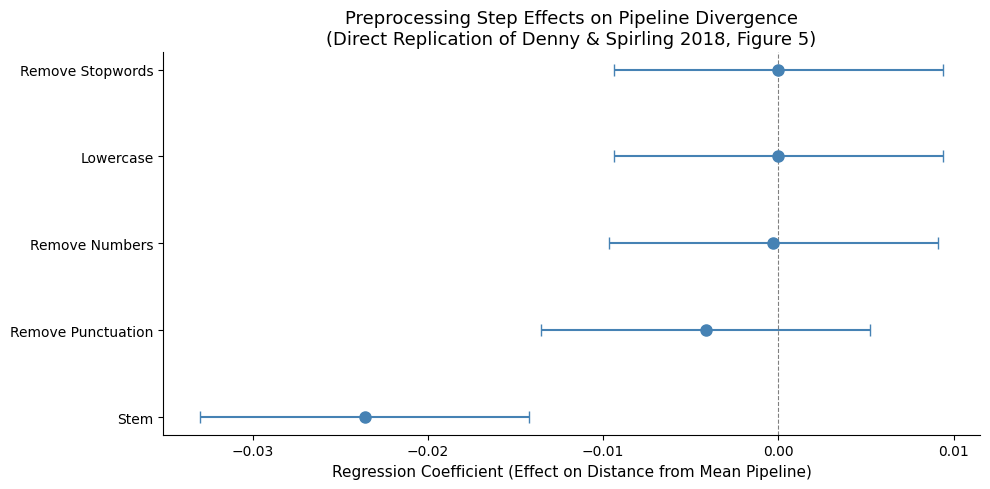

In [67]:
import statsmodels.api as sm

# Step 1: Compute the 'mean pipeline' — the element-wise average of all 32
# cosine similarity matrices. This will be the 'consensus' view of the corpus.
all_matrices = np.array([pipeline_results[label] for label in pipeline_labels])
mean_matrix = all_matrices.mean(axis=0)

# Step 2: For each pipeline, measure its distance from the mean pipeline (mean absolute difference in cosine similarity). This is the outcome variable.
distances = np.array([
    np.mean(np.abs(pipeline_results[label] - mean_matrix))
    for label in pipeline_labels
])

# Step 3: Build the predictor matrix — one binary column per preprocessing step.
# Each row corresponds to one of the 32 pipelines; each column indicates whether a given step was applied in that pipeline.
X = np.array([list(combo) for combo in combinations]).astype(int)
X_df = pd.DataFrame(X, columns=step_names)

# Step 4: Fit OLS regression — distance from mean ~ preprocessing step flags.
# Adding a constant captures the intercept (baseline distance when no steps applied).
X_with_const = sm.add_constant(X_df)
model = sm.OLS(distances, X_with_const).fit()


# Step 5: Extract coefficients and 95% confidence intervals for plotting - drop the intercept because it isn't a preprocessing-step effect.
coefs = model.params.drop('const')
conf_int = model.conf_int().drop('const')
conf_int.columns = ['lower', 'upper']

# Sort steps by coefficient so the biggest effect appears at the top
order = coefs.sort_values(ascending=True).index
coefs = coefs.loc[order]
conf_int = conf_int.loc[order]

# Error bars: distance from coefficient to each end of the confidence interval
err_lower = coefs - conf_int['lower']
err_upper = conf_int['upper'] - coefs

# Plot: horizontal points with error bars — direct equivalent of Figure 5 from original study
fig, ax = plt.subplots(figsize=(10, 5))
formatted_names = [n.replace('_', ' ').title() for n in coefs.index]
ax.errorbar(
    coefs.values,
    formatted_names,
    xerr=[err_lower.values, err_upper.values],
    fmt='o',
    color='steelblue',
    ecolor='steelblue',
    capsize=4,
    markersize=8
)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Regression Coefficient (Effect on Distance from Mean Pipeline)', fontsize=11)
ax.set_title(
    'Preprocessing Step Effects on Pipeline Divergence\n'
    '(Direct Replication of Denny & Spirling 2018, Figure 5)',
    fontsize=13
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Step 9: Summary statistics for my replication



In [68]:
# Summary statistics

print("SUMMARY Stats")
print()
print(f"Number of documents in corpus: {len(documents)}")
print(f"Number of preprocessing pipelines tested: {len(combinations)}")
print(f"Number of preprocessing steps varied: {len(step_names)}")
print(f"Steps tested: {', '.join(step_names)}")
print()

# Most and least sensitive steps
sorted_sens = sorted(sensitivity.items(), key=lambda x: x[1], reverse=True)
print(f"Most sensitive step:  {sorted_sens[0][0]} (effect: {sorted_sens[0][1]:.6f})")
print(f"Least sensitive step: {sorted_sens[-1][0]} (effect: {sorted_sens[-1][1]:.6f})")
print()

# Overall variation across pipelines
all_diffs = cross_pipeline_diffs[np.triu_indices(n_pipelines, k=1)]
print(f"Average difference between pipeline pairs: {np.mean(all_diffs):.6f}")
print(f"Maximum difference between any two pipelines: {np.max(all_diffs):.6f}")

SUMMARY Stats

Number of documents in corpus: 69
Number of preprocessing pipelines tested: 32
Number of preprocessing steps varied: 5
Steps tested: lowercase, remove_punctuation, remove_numbers, remove_stopwords, stem

Most sensitive step:  remove_stopwords (effect: 0.394966)
Least sensitive step: lowercase (effect: 0.000000)

Average difference between pipeline pairs: 0.211022
Maximum difference between any two pipelines: 0.421820
